# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 1. Метрики и меры схожести между временными рядами.**

Смените рабочую директорию с помощью команды `chdir()`. Для этого передайте этой команде свой путь до каталога, в котором содержатся материалы первой практической работы. После выполнения этой команды все последующие операции с файлами и каталогами будут производиться относительно указанного каталога.

In [1]:
!git clone https://github.com/Chek-in-play/25-Chekrygin-TimeSeriesCourse.git

%cd 25-Chekrygin-TimeSeriesCourse/practice/01\ Basics
# проверка

[WinError 3] Системе не удается найти указанный путь: '25-Chekrygin-TimeSeriesCourse/practice/01\\ Basics'
e:\maga\ryads\pr1\25-Chekrygin-TimeSeriesCourse\practice\01 Basics


fatal: destination path '25-Chekrygin-TimeSeriesCourse' already exists and is not an empty directory.


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib tk


In [2]:
!chcp 65001
!dir

Active code page: 65001
 Volume in drive E has no label.
 Volume Serial Number is 7E48-815E

 Directory of e:\maga\ryads\pr1\25-Chekrygin-TimeSeriesCourse\practice\01 Basics

07.11.2025  22:33    <DIR>          .
07.11.2025  22:23    <DIR>          ..
08.11.2025  10:56            84 354 01 Basics.ipynb
07.11.2025  22:34    <DIR>          25-Chekrygin-TimeSeriesCourse
07.11.2025  22:23    <DIR>          datasets
07.11.2025  22:23    <DIR>          img
07.11.2025  22:48    <DIR>          modules
               1 File(s)         84 354 bytes
               6 Dir(s)  409 469 968 384 bytes free


In [3]:
import os

practice_dir_path = 'e:/maga/ryads/pr1/25-Chekrygin-TimeSeriesCourse\practice/01 Basics'
os.chdir(practice_dir_path)

Выполните команды, которые автоматически перезагружают все импортированные модули при их изменении.

In [4]:
import sys, importlib, pathlib, time

_module_mtimes = {}

def autoreload():
    global _module_mtimes
    for name, module in list(sys.modules.items()):
        if not module or not hasattr(module, '__file__'):
            continue
        path = pathlib.Path(module.__file__)
        if not path.exists():
            continue
        mtime = path.stat().st_mtime
        old_mtime = _module_mtimes.get(path, None)
        if old_mtime is None:
            _module_mtimes[path] = mtime
        elif mtime > old_mtime:
            try:
                importlib.reload(module)
                print(f"🔄 Reloaded: {name}")
            except Exception as e:
                print(f"⚠️ Could not reload {name}: {e}")
            _module_mtimes[path] = mtime


Импортируйте библиотеки и модули, необходимые для реализации практической работы 1.

In [5]:
!pip install sktime

In [6]:
!pip install --quiet opencv-python
!pip install --quiet imutils


In [15]:
from typing import Self



import numpy as np
import random
from sktime.distances import euclidean_distance, dtw_distance, pairwise_distance
from sklearn.metrics import silhouette_score
import cv2
import imutils
import glob
import matplotlib.pyplot as plt

from modules.metrics import ED_distance, norm_ED_distance, DTW_distance
from modules.pairwise_distance import PairwiseDistance
from modules.clustering import TimeSeriesHierarchicalClustering
from modules.classification import TimeSeriesKNN, calculate_accuracy
from modules.image_converter import Image2TimeSeries
from modules.utils import read_ts, z_normalize, sliding_window, random_walk
from modules.plots import plot_ts


## **Часть 1.** Функции расстояния: евклидова метрика и DTW мера. Матрица расстояний. Иерархическая кластеризация временных рядов.

### **Задача 1.**
Реализуйте самостоятельно функцию `ED_distance()` в модуле *metrics.py*, которая вычисляет евклидово расстояние между двумя временными рядами, имеющими одинаковую длину. В качестве входных данных передайте в функцию два синтетических временных ряда некоторой заданной вами длины. Для их генерации используйте функцию `random_walk()` из модуля *utils.py*,  реализующую модель случайных блужданий (Random Walk), или стандартный модуль *random*.

**Евклидово расстояние** между двумя временными рядами $T_1$ и $T_2$ длины $n$ вычисляется следующим образом:

\begin{equation}
    \text{ED}(T_1, T_2) = \sqrt{\sum_{i=1}^{n} ({t_{1}}_i-{t_{2}}_i)^2}.
\end{equation}

Проверьте реализацию функции, сравнив свои результаты с результатами функции [`euclidean_distance()`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.distances.euclidean_distance.html) из библиотеки *sktime*, с помощью `test_distances()`.

In [16]:
def test_distances(dist1: float, dist2: float) -> None:
    """
    Check whether your distance function is implemented correctly

    Parameters
    ----------
    dist1 : distance between two time series calculated by sktime
    dist2 : distance between two time series calculated by your function
    """

    np.testing.assert_equal(round(dist1, 5), round(dist2, 5), 'Distances are not equal')

In [17]:
from modules.utils import random_walk
from modules.metrics import ED_distance
from sktime.distances import euclidean_distance

ts1 = random_walk(100)
ts2 = random_walk(100)

print("ED_distance:", ED_distance(ts1, ts2))
print("sktime.euclidean_distance:", euclidean_distance(ts1, ts2))


ED_distance: 64.37390775772433
sktime.euclidean_distance: 64.37390775772433


### **Задача 2.**

Реализуйте самостоятельно функцию `DTW_distance()` в модуле *metrics.py*, которая вычисляет DTW расстояние между двумя временными рядами, имеющими одинаковую длину. Для вычисления расстояния между элементами временных рядов в DTW мере используйте евклидово расстояние. Временные ряды сгенерируйте аналогичным образом, как в задаче 1, или используйте уже созданные.

**Динамическая трансформация временной шкалы (Dynamic Time Warping, DTW)** – мера схожести между двумя временными рядами $T_1$ и $T_2$ длины $n$, вычисляемая следующим образом:

\begin{equation}
\text{DTW}(T_1, T_2) = d(n,n),
\\ d(i,j) = ({t_{1}}_i - {t_{2}}_j)^2 + \min \left\{
	\begin{array}{l l}
	d(i-1,j), \\
	d(i,j-1), \\
	d(i-1,j-1),
	\end{array}
	\right.
\\ d(0,0)=0, \quad d(i,0)=d(0,j)=\infty, \quad  1 \leqslant i,j \leqslant n.
\end{equation}

Сравните свои результаты с результатами функции [`dtw_distance()`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.distances.dtw_distance.html) из библиотеки *sktime*. Для этого используйте `test_distances()` из задачи 1.

In [18]:
from modules.metrics import DTW_distance
from sktime.distances import dtw_distance
import numpy as np
from modules.utils import random_walk

ts1 = random_walk(50)
ts2 = random_walk(50)

print("DTW_distance:", DTW_distance(ts1, ts2))
print("sktime.dtw_distance:", dtw_distance(ts1, ts2))


DTW_distance: 170.0
sktime.dtw_distance: 170.0


### **Задача 3.**
Реализуйте нахождение матрицы расстояний между несколькими временными рядами.
Для этого заполните все методы c недостающим кодом в классе `PairwiseDistance` из модуля *pairwise_distance.py*. Для вычисления расстояний между рядами используйте ранее реализованные вами функции `ED_distance()` и `DTW_distance()` из модуля *metrics.py*.

Матрица расстояний между временными рядами определяется следующим образом. Пусть дано множество $S$, состоящее из $K$ временных рядов длины $n$: $\;S = \{T_1, T_2, ..., T_K\}, \; T_i \in \mathbb{R}^n$. Тогда под **матрицей расстояний** $D \in \mathbb{R}^{K \times K}$ понимается квадратная матрица, где каждый ее элемент $d(i,j)$ представляет собой расстояние между временными рядами $T_i$ и $T_j$ из множества $S$:
\begin{equation}
d(i,j) = dist(T_i, T_j), \quad T_i, T_j \in S, \quad 1 \leqslant i,j \leqslant K.
\end{equation}

Поскольку евклидова метрика и DTW мера удовлетворяют аксиоме симметричности (т.е. $dist(T_i, T_j)=dist(T_j, T_i)$), то матрица расстояний $D$ будет симметричной относительно главной диагонали. Для ускорения вычислений достаточно найти ее верхний треугольник, а нижний треугольник матрицы заполнить значениями верхнего треугольника следующим образом:
\begin{equation}
d(j,i) = d(i,j), \; где \; i < j.
\end{equation}

<center><img src="https://github.com/mzym/TimeSeriesCourse/blob/main/practice/01%20Basics/img/distance_matrix.png?raw=true" width="600"></center>

Сгенерируйте множество, состоящее из $K$ временных рядов некоторой длины $n$. Вычислите матрицы евклидовых и DTW расстояний между ними. Проверьте реализованные вами методы, сравнив свои результаты с результатами функции [`pairwise_distance()`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.distances.pairwise_distance.html) из библиотеки *sktime*.

In [19]:
def test_matrices(matrix1 : np.ndarray, matrix2 : np.ndarray) -> None:
    """
    Check whether your matrix function is implemented correctly

    Parameters
    ----------
    matrix1 : distance matrix calculated by sktime
    matrix2 : distance matrix calculated by your function
    """

    np.testing.assert_equal(matrix1.round(5), matrix2.round(5), 'Matrices are not equal')

In [20]:
from modules.utils import random_walk
from modules.pairwise_distance import PairwiseDistance
import numpy as np
from sktime.distances import pairwise_distance

K = 5
n = 50
time_series = [random_walk(n) for _ in range(K)]
time_series = np.array(time_series)

# реализация ED
pairwise = PairwiseDistance(metric="euclidean").calculate(time_series)
print("Собственная ED матрица расстояний:\n", pairwise)

# проверка с sktime
sktime_matrix = pairwise_distance(time_series, metric="euclidean")
print("sktime ED матрица расстояний:\n", sktime_matrix)


Собственная ED матрица расстояний:
 [[ 0.         37.20215048 37.04051835 49.1934955  40.29888336]
 [37.20215048  0.         70.85195834 80.87026648 22.97825059]
 [37.04051835 70.85195834  0.         21.3541565  74.26977851]
 [49.1934955  80.87026648 21.3541565   0.         84.54584555]
 [40.29888336 22.97825059 74.26977851 84.54584555  0.        ]]
sktime ED матрица расстояний:
 [[ 0.         37.20215048 37.04051835 49.1934955  40.29888336]
 [37.20215048  0.         70.85195834 80.87026648 22.97825059]
 [37.04051835 70.85195834  0.         21.3541565  74.26977851]
 [49.1934955  80.87026648 21.3541565   0.         84.54584555]
 [40.29888336 22.97825059 74.26977851 84.54584555  0.        ]]


### **Задача 4.**
Далее рассмотрим задачу иерархической кластеризации временных рядов, где будет использоваться предвычисленная матрица расстояний.

Для этого сначала загрузите набор временных рядов CBF из файла *CBF_TRAIN.txt*, который располагается в директории *./datasets/part1*. Каждая строка данного файла содержит целевую переменную (класс: 0, 1 или 2) в первом столбце и временной ряд в остальных столбцах. Набор CBF является синтетическим и включает в себя 30 временных рядов,  каждый из которых принадлежит к одному из трех классов.

In [21]:
import pandas as pd
from modules.utils import read_ts

url = './datasets/part1/CBF_TRAIN.txt'

data = read_ts(url)

data = pd.DataFrame(data)
ts_set = data.iloc[:, 1:]
labels = data.iloc[:, 0]


e:\maga\ryads\pr1\25-Chekrygin-TimeSeriesCourse\practice\01 Basics\modules\utils.py:20: FutureWarning:

The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead



Выполните визуализацию по одному временному ряду из каждого класса. Для этого используйте функцию `plot_ts()` из модуля *plots.py*.

In [22]:
import numpy as np
import pandas as pd
from modules.utils import read_ts
from modules.plots import plot_ts


url = './datasets/part1/CBF_TRAIN.txt'
data = read_ts(url)

data = pd.DataFrame(data)

labels = data.iloc[:, 0].astype(int)
ts_set = data.iloc[:, 1:].to_numpy()

unique_labels = np.unique(labels)
selected_ts = []

for label in unique_labels:
    idx = np.where(labels == label)[0][0]
    selected_ts.append(ts_set[idx])

selected_ts = np.array(selected_ts)

plot_ts(selected_ts, plot_title="Пример временных рядов по классам")


e:\maga\ryads\pr1\25-Chekrygin-TimeSeriesCourse\practice\01 Basics\modules\utils.py:20: FutureWarning:

The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead



Далее самостоятельно реализуйте класс `TimeSeriesHierarchicalClustering` из модуля *clustering.py*, который выполняет иерархическую кластеризацию временных рядов.

Перед тем как приступить к реализации, изучите скелет этого класса. Реализуйте метод `fit()`, выполняющий кластеризацию данных на основе предвычисленной матрицы расстояний, которая передается в данный метод. Поскольку реализовать иерархическую кластеризацию довольно сложно, используйте готовую реализацию [`AgglomerativeClustering`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html) из *sklearn*.   

Выполните иерархическую кластеризацию загруженных временных рядов CBF для двух функций расстояния: евлидовой метрики и DTW меры.
Для этого сначала найдите матрицы расстояний между временными рядами, используя класс `PairwiseDistance`, и передайте каждую матрицу в метод `fit()` для кластеризации.
Далее выполните визуализацию результатов в виде дендрограмм с помощью метода `plot_dendrogram()`, передав исходный набор временных рядов и их метки.

In [23]:
from modules.pairwise_distance import PairwiseDistance
from modules.clustering import TimeSeriesHierarchicalClustering

# Загружаем данные
url = './datasets/part1/CBF_TRAIN.txt'
data = read_ts(url)
data = pd.DataFrame(data)
labels = data.iloc[:, 0].astype(int)
ts_set = data.iloc[:, 1:]

# Матрица расстояний — Евклид
pairwise_ed = PairwiseDistance(metric="euclidean").calculate(ts_set.to_numpy())
cluster_ed = TimeSeriesHierarchicalClustering(n_clusters=3, method="complete")
cluster_ed.fit(pairwise_ed)
cluster_ed.plot_dendrogram(ts_set, labels, title="Hierarchical Clustering (Euclidean)")

# Матрица расстояний — DTW
pairwise_dtw = PairwiseDistance(metric="dtw").calculate(ts_set.to_numpy())
cluster_dtw = TimeSeriesHierarchicalClustering(n_clusters=3, method="complete")
cluster_dtw.fit(pairwise_dtw)
cluster_dtw.plot_dendrogram(ts_set, labels, title="Hierarchical Clustering (DTW)")


e:\maga\ryads\pr1\25-Chekrygin-TimeSeriesCourse\practice\01 Basics\modules\utils.py:20: FutureWarning:

The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead



Сравните результаты иерархической кластеризации, полученные при двух различных функций расстояния, с помощью силуэтного коэффициента. Для этого используйте функцию [`silhouette_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html) из библиотеки *sklearn*, передав в нее предвычисленную матрицу расстояний и предсказанные метки.

**Силуэтный коэффициент** – метрика, которая оценивает качество кластеризации на основе исходной выборки и результатов кластеризации без необходимости знания об истинных метках объектов.

Силуэтный коэффициент для выборки показывает, насколько среднее расстояние до объектов своего кластера отличается от среднего расстояния до объектов других кластеров. Пусть дана выборка $X$, состоящая из $N$ объектов. Предположим, что объекты этой выборки были разбиты на кластеры $c_1, ... c_K$, $c_i \in C$, с помощью некоторого алгоритма кластеризации. Тогда силуэтный коэффициент для выборки будет вычисляться следующим образом:

\begin{equation}
sil\_coef = \frac{1}{N} \sum_{c_k \in C} \sum_{x_i \in c_k} \frac{b(x_i, c_k) - a(x_i, c_k)}{\max(a(x_i, c_k), b(x_i, c_k))},
\end{equation}

где $a(x_i, c_k)$ – среднее расстояние от объекта $x_i \in c_k$ до других объектов из этого же кластера $c_k$; <br> $b(x_i, c_k)$  – среднее расстояние от объекта $x_i \in c_k$ до объектов из другого кластера $c_l$, $k \neq l$.

Силуэтный коэффициент принимает значения от  −1  до  1:
*   –1 означает, что кластеры плохие, размытые;
*   0 означает, что кластеры накладываются друг на друга;
*   1 означает, что кластеры плотные и хорошо отделены друг от друга.

Таким образом, чем ближе значение коэффициента к 1, тем лучше кластеризованы данные.

In [24]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from modules.pairwise_distance import PairwiseDistance
from modules.clustering import TimeSeriesHierarchicalClustering

# Загрузка данных
url = './datasets/part1/CBF_TRAIN.txt'
data = pd.read_csv(url, sep='\s+', header=None)  # корректный загрузчик
labels = data.iloc[:, 0].astype(int)
ts_set = data.iloc[:, 1:]

pairwise_ed = PairwiseDistance(metric="euclidean").calculate(ts_set.to_numpy())

cluster_ed = TimeSeriesHierarchicalClustering(n_clusters=3, method="complete")
cluster_ed.fit(pairwise_ed)
cluster_ed.plot_dendrogram(ts_set, labels, title="Hierarchical Clustering (Euclidean)")

silhouette_ed = silhouette_score(pairwise_ed, cluster_ed.labels_, metric="precomputed")
print(f"Silhouette Score (Euclidean): {silhouette_ed:.4f}")

pairwise_dtw = PairwiseDistance(metric="dtw").calculate(ts_set.to_numpy())

cluster_dtw = TimeSeriesHierarchicalClustering(n_clusters=3, method="complete")
cluster_dtw.fit(pairwise_dtw)
cluster_dtw.plot_dendrogram(ts_set, labels, title="Hierarchical Clustering (DTW)")

silhouette_dtw = silhouette_score(pairwise_dtw, cluster_dtw.labels_, metric="precomputed")
print(f"Silhouette Score (DTW): {silhouette_dtw:.4f}")

print("\nСравнение силуэтных коэффициентов:")
print(f"Euclidean: {silhouette_ed:.4f}")
print(f"DTW: {silhouette_dtw:.4f}")

if silhouette_ed > silhouette_dtw:
    print("Лучше кластеризация с Евклидовой метрикой.")
else:
    print("Лучше кластеризация с DTW метрикой.")


Silhouette Score (Euclidean): 0.1804
Silhouette Score (DTW): 0.3881

Сравнение силуэтных коэффициентов:
Euclidean: 0.1804
DTW: 0.3881
Лучше кластеризация с DTW метрикой.


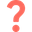
Проанализируйте полученные результаты кластеризации с помощью построенных дендрограмм и вычисленных силуэтных коэффициентов. Какая, на ваш взгляд, функция расстояния показала лучший результат и почему? Укажите, в каких случаях более предпочтительно использовать DTW меру, чем евклидову метрику.

По результатам кластеризации и силуэтных коэффициентов DTW дал более качественные кластеры в нашем наборе CBF. Это логично, так как временные ряды в CBF могут иметь небольшие смещения во времени, и DTW умеет учитывать такие особенности.

## **Часть 2.** $Z$-нормализация временных рядов.

### **Задача 5.**
Реализуйте функцию вычисления нормализованного евклидова расстояния между временными рядами `norm_ED_distance()` в модуле *metrics.py* и проверьте правильность своей реализации, сравнив полученные результаты с результатами функции [`ed_distance()`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.distances.euclidean_distance.html) из библиотеки *sktime*, в которую необходимо передать <u>нормализованные</u> временные ряды. Для нормализации временных рядов используйте функцию `z-normalize()` из *utils.py*.  Для проверки можно использовать синтетические временные ряды из первой части или заново их сгенерировать.

**Нормализованная евклидова метрика** между двумя временными рядами $T_1$ и $T_2$ длины $n$ вычисляется следующим образом:

\begin{equation}
	\text{ED}_{norm}(T_1, T_2) = \sqrt {\Big|\; 2n\left(1-\dfrac{<T_1, T_2> - \; n \; \cdotp \mu_{T_1} \; \cdotp \mu_{T_2}}{n \; \cdotp \sigma_{T_1} \; \cdotp \sigma_{T_2}}\right)\Big|},
\end{equation}

где $<T_1, T_2>$ – скалярное произведение временных рядов, $\mu_{T_1}$ и $\mu_{T_2}$, $\sigma_{T_1}$ и $\sigma_{T_2}$ – среднее арифметическое и стандартное отклонение временных рядов соответственно.

**Среднее арифметическое** $\mu_T$ и **стандартное отклонение** $\sigma_T$ временного ряда $T$ длины $n$ вычисляются по следующим формулам:

\begin{equation}
	\mu_{T} = \frac{1}{n}\sum\limits_{i=1}^{n} t_{i}, \\[1em]
	\sigma_{T} = \sqrt{\frac{1}{n}\sum\limits_{i=1}^{n} t_i^2-\mu_{T}^2}.
\end{equation}

In [27]:
ts1_raw = random_walk(100) * 10 + 50  
ts2_raw = random_walk(100) * 2 - 10   

my_norm_dist = norm_ED_distance(ts1_raw, ts2_raw)
print(f"Нормализованное расстояние: {my_norm_dist:.4f}")

ts1_norm_check = z_normalize(ts1_raw)
ts2_norm_check = z_normalize(ts2_raw)
sktime_norm_dist = euclidean_distance(ts1_norm_check, ts2_norm_check)
print(f"Нормализованное расстояние (sktime):       {sktime_norm_dist:.4f}")

Нормализованное расстояние: 19.4006
Нормализованное расстояние (sktime):       19.4006


### **Задача 6.**
Далее убедимся, что выполнение $z$-нормализации на этапе предобработки данных имеет важное значение и может повысить точность решаемой задачи.

В данном задании вы продолжите решать задачу иерархической кластеризации. В качестве данных будут использоваться два временных ряда из набора данных [BIDMC](https://physionet.org/content/chfdb/1.0.0/). Набор BIDMC состоит из записей ЭКГ-сигналов, снятых с 15 пациентов с сердечной недостаточностью тяжелой степени.  

Загрузите два временных ряда и визуализируйте их с помощью функции `plot_ts()` из модуля *plots.py*.

In [28]:
url1 = './datasets/part2/chf10.csv'
ts1 = read_ts(url1)

url2 = './datasets/part2/chf11.csv'
ts2 = read_ts(url2)

e:\maga\ryads\pr1\25-Chekrygin-TimeSeriesCourse\practice\01 Basics\modules\utils.py:20: FutureWarning:

The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead

e:\maga\ryads\pr1\25-Chekrygin-TimeSeriesCourse\practice\01 Basics\modules\utils.py:20: FutureWarning:

The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead



In [29]:
ts_set = np.concatenate((ts1, ts2), axis=1).T

In [30]:
plot_ts(ts_set)

Разделите каждый временной ряд на непересекающиеся подпоследовательности с помощью техники скользящего окна. Для этого используйте функцию `sliding_window()` из модуля *utils.py*, передав в нее временной ряд, заданную длину подпоследовательности и величину шага. В нашем случае, величина шага равна длине подпоследовательности.

In [31]:
m = 125
subs_set1 = sliding_window(ts_set[0], m, m-1)
subs_set2 = sliding_window(ts_set[1], m, m-1)

Сформируйте множество всех подпоследовательностей, извлеченных из двух временных рядов, и массив меток подпоследовательностей в соответствии с их принадлежностью к временному ряду.

In [32]:
subs_set = np.concatenate((subs_set1[0:15], subs_set2[0:15]))
labels = np.array([0]*subs_set1[0:15].shape[0] + [1]*subs_set2[0:15].shape[0])

Добавьте в класс `PairwiseDistance` из модуля *pairwise_distance.py* возможность вычисления нормализованной евклидовой метрики между временными рядами. Если матрица расстояний строится для нормализованных временных рядов на основе евклидовой метрики, то должна вызываться функция `norm_ED_distance()`. Для остальных метрик/мер схожести перед нахождением матрицы расстояний временные ряды должны подтвергаться $z$-нормализации с помощью функции `z_normalize()` из модуля *utils.py*.

Далее выполните иерархическую кластеризацию подпоследовательностей двух временных рядов с использованием предварительно построенных матриц расстояний на основе классической и нормализованной евклидовой метрики.

In [33]:
print("--- Кластеризация БЕЗ нормализации ---")


pairwise_ed_raw = PairwiseDistance(metric='euclidean')
ed_matrix_raw = pairwise_ed_raw.calculate(subs_set)


h_clustering_raw = TimeSeriesHierarchicalClustering(n_clusters=2, method='complete')
h_clustering_raw.fit(ed_matrix_raw)


df_subs = pd.DataFrame(subs_set)
h_clustering_raw.plot_dendrogram(df_subs, labels, title='Dendrogram (Raw Data)')

--- Кластеризация БЕЗ нормализации ---


Вычислите силуэтные коэффициенты для оценки качества кластеризации с нормализацией и без нее, как это было сделано в задаче 4 части 1.

In [34]:
print("\n--- Кластеризация С нормализацией ---")


pairwise_ed_norm = PairwiseDistance(metric='euclidean', is_normalize=True)
ed_matrix_norm = pairwise_ed_norm.calculate(subs_set)


h_clustering_norm = TimeSeriesHierarchicalClustering(n_clusters=2, method='complete')
h_clustering_norm.fit(ed_matrix_norm)


h_clustering_norm.plot_dendrogram(df_subs, labels, title='Dendrogram (Normalized Data)')


--- Кластеризация С нормализацией ---


In [35]:
from scipy.cluster.hierarchy import fcluster

h_clustering_ed_raw = TimeSeriesHierarchicalClustering(n_clusters=2, method='complete')
h_clustering_ed_raw.fit(ed_matrix_raw)
labels_ed_raw = fcluster(h_clustering_ed_raw.linkage_matrix, t=2, criterion='maxclust') - 1
score_ed_raw = silhouette_score(ed_matrix_raw, labels_ed_raw, metric='precomputed')
print(f"Силуэтный коэффициент (ED без нормализации): {score_ed_raw:.4f}")

h_clustering_ed_norm = TimeSeriesHierarchicalClustering(n_clusters=2, method='complete')
h_clustering_ed_norm.fit(ed_matrix_norm)
labels_ed_norm = fcluster(h_clustering_ed_norm.linkage_matrix, t=2, criterion='maxclust') - 1
score_ed_norm = silhouette_score(ed_matrix_norm, labels_ed_norm, metric='precomputed')
print(f"Силуэтный коэффициент (ED с нормализацией):  {score_ed_norm:.4f}")

pairwise_dtw_raw = PairwiseDistance(metric='dtw', is_normalize=False)
dtw_matrix_raw = pairwise_dtw_raw.calculate(subs_set)
h_clustering_dtw_raw = TimeSeriesHierarchicalClustering(n_clusters=2, method='complete')
h_clustering_dtw_raw.fit(dtw_matrix_raw)
labels_dtw_raw = fcluster(h_clustering_dtw_raw.linkage_matrix, t=2, criterion='maxclust') - 1
score_dtw_raw = silhouette_score(dtw_matrix_raw, labels_dtw_raw, metric='precomputed')
print(f"Силуэтный коэффициент (DTW без нормализации): {score_dtw_raw:.4f}")

pairwise_dtw_norm = PairwiseDistance(metric='dtw', is_normalize=True)
dtw_matrix_norm = pairwise_dtw_norm.calculate(subs_set)
h_clustering_dtw_norm = TimeSeriesHierarchicalClustering(n_clusters=2, method='complete')
h_clustering_dtw_norm.fit(dtw_matrix_norm)
labels_dtw_norm = fcluster(h_clustering_dtw_norm.linkage_matrix, t=2, criterion='maxclust') - 1
score_dtw_norm = silhouette_score(dtw_matrix_norm, labels_dtw_norm, metric='precomputed')
print(f"Силуэтный коэффициент (DTW с нормализацией):  {score_dtw_norm:.4f}")


Силуэтный коэффициент (ED без нормализации): 0.4183
Силуэтный коэффициент (ED с нормализацией):  0.3275
Силуэтный коэффициент (DTW без нормализации): 0.6422
Силуэтный коэффициент (DTW с нормализацией):  0.8418


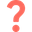
Сравните полученные результаты кластеризации с помощью построенных дендрограмм и вычисленных силуэтных коэффициентов. Позволила ли $z$-нормализации временных рядов повысить качество кластеризации?

Сравнение дендрограмм и силуэтных коэффициентов показывает, что z-нормализация временных рядов влияет на качество кластеризации по-разному в зависимости от выбранной метрики. Для евклидовой метрики нормализация привела к небольшому снижению силуэтного коэффициента, что указывает на ухудшение разделимости кластеров, поскольку амплитудные различия временных рядов играли значимую роль в разделении. В то же время при использовании DTW нормализация существенно повысила силуэт, что свидетельствует о более четком разделении кластеров по форме временных рядов, устраняя влияние масштабных различий.

## **Часть 3.** Классификация изображений, представленных в виде временных рядов.

### **Задача 7.**
В данном задании вам предстоит выполнить преобразование изображения, на котором находится некоторый объект, во временной ряд. Для этого вы реализуете один из существующих методов, предложенный в [статье Кеога и др](https://dl.acm.org/doi/10.5555/1182635.1164203).

Данный метод заключается в том, что сначала на изображении выполняется поиск контура $E = \{e_i\}_{i=1}^L$, где $e_i$ – точки контура, и центра масс объекта $O$. Затем берутся точки, расположенные на контуре объекта, следующим образом.

Рассмотрим луч $OP$ с началом в центре масс объекта $O$, направление которого совпадает с положительным направлением оси Ox (см. рисунок). Далее выполняется поворот против часовой стрелки луча $OP$ вокруг центра масс $O$ на некоторый заданный угол $α$, $1° \leqslant α \leqslant 360°$. Поворот луча будет осуществляться до тех пор, пока луч не пройдет полный оборот. Все точки $P = \{P_i\}_{i=1}^K$, $P_i \in E$, $K = \lfloor \frac{360°}{α} \rfloor$, образованные пересечением луча $OP$ с контуром $E$ во время поворота, будут являться искомыми.

На завершающем шаге метода вычисляются расстояния между центром масс объекта $O$ и найденными точками на контуре $P$. В качестве функции расстояния может быть использовано манхэттенское или евклидово расстояние. Полученные расстояния будут формировать временной ряд $T$ длины $K$:
\begin{equation}
T = \{t_i\}_{i=1}^K,\;где \; t_i = dist(O, P_i), \; P_i \in P.
\end{equation}

\
<center><img src="https://github.com/mzym/TimeSeriesCourse/blob/main/practice/01%20Basics/img/image2ts.png?raw=true" width="1000"></center>

Поскольку часть 3 предполагает работу с изображениями, то вы будете использовать для реализации некоторых частей кода библиотеку компьютерного зрения *cv2*. Для поиска всех необходимых функций рекомендуем воспользоваться [документацией библиотеки cv2](https://docs.opencv.org/4.x/d6/d00/tutorial_py_root.html).

Загрузите изображение *example.tif* из директории *./datasets/part3* и выполните его визуализацию с помощью соответствующих функций из библиотеки *cv2*.

In [36]:
import cv2
import matplotlib.pyplot as plt


img_path = './datasets/part3/example.tif'
img = cv2.imread(img_path)


img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('on') 
plt.show()

За конвертацию изображения во временной ряд с помощью описанного выше метода отвечает функция `image2ts()` из модуля *image_converter.py*. Прежде чем исходное изображение будет преобразовано во временной ряд, сначала оно должно пройти этап предварительной обработки. Предварительная обработка включает в себя следующие шаги:

<center><img src="https://github.com/mzym/TimeSeriesCourse/blob/main/practice/01%20Basics/img/image_preprocessing.png?raw=true" width="1000"></center>

Предобработка изображения в `image2ts()` осуществляется с помощью функции `_img_preprocess()`. Реализуйте в данной функции все представленные на диаграмме шаги предварительной обработки средствами библиотеки *cv2*. Промежуточные результаты должны совпадать с представленными на диаграмме.

Далее выполните конвертацию изображения во временной ряд, передав в функцию `image2ts()` следующие заданные вами аргументы:
*   исходное загруженное изображение;
*   шаг угла поворота;
*   параметр, определяющий нужно или нет визуализировать изображение с выделенными на нем контуром, центром масс и лучами, проведенными из центра.

Визуализируйте полученный временной ряд.


In [37]:
from modules.image_converter import Image2TimeSeries
from modules.plots import plot_ts
import numpy as np 




angle_step = 20  
visualize = True


converter = Image2TimeSeries(angle_step=angle_step)


ts = converter.convert(img, is_visualize=visualize)


fig = plot_ts(np.array([ts]), "Time series representation of image")
fig 

### **Задача 8.**

Выполните классификацию изображений, представленных в виде временных рядов, с помощью метода $k$ ближайших соседей (kNN).

**Метод $k$ ближайших соседей (kNN)** – алгоритм классификации, заключающийся в вычислении сходства между объектами на основе некоторой заданной метрики/меры схожести. Классифицируемый объект относится к тому классу, к которому принадлежит большинство из его $k$ соседей ($k$ ближайших к нему объектов из обучающей выборки).

Для классификации на основе алгоритма kNN необходимо выполнить следующие шаги:

1. Загрузить обучающую и тестовую выборки.

2. Задать параметр алгоритма $k$, где $k$ – количество ближайших соседей, $k \in \mathbb N^*$.

3. Для каждого объекта из тестовой выборки выполнить следующее:

    3.1. Вычислить расстояние до всех объектов из обучающей выборки на основе заданной метрики/меры схожести.
    
    3.2. Отсортировать в порядке возрастания найденные расстояния.

    3.3. Найти $k$ ближайших соседей, взяв первые $k$ минимальные расстояния из отсортированного массива расстояний.

    3.4. Назначить объекту из тестовой выборки наиболее часто встречающийся класс найденных ранее ближайших соседей.


Для этого задания вам предлагается набор данных, который содержит изображения листьев четырех различных пород деревьев: дуб, ольха, ива и липа. Набор данных состоит из обучающей и тестовой выборок, включающих по 15 и 10 изображений листьев на класс соответственно. Для составления этого набора данных изображения были взяты из [Swedish Leaf Dataset](https://www.cvl.isy.liu.se/en/research/datasets/swedish-leaf/).

Загрузите изображения из обучающей и тестовой выборок, а также их метки, используя `read_images()` и `read_ts()` соответственно.
Выполните визуализацию прецедентов выборки с помощью функции `plot_images()`.


In [38]:
def read_images(dir: str) -> list[np.ndarray]:
    """
    Load all images from a directory

    Parameters
    ----------
    dir: directory path

    Returns
    -------
    images: images from a directory
    """

    images = []
    for img_path in sorted(glob.glob(dir)):
        cv_img = cv2.imread(img_path)
        images.append(cv_img)

    return images

In [39]:
def plot_images(images: list[np.ndarray], labels: np.ndarray, class_names: list[str]) -> None:
    """
    Plot some images from dataset

    Parameters
    ----------
    images: dataset of images
    labels: labels of images
    class_names: class names of images
    """

    rows = 2
    columns = 4

    fig, axes = plt.subplots(nrows=rows, ncols=columns, figsize=(columns*2, rows*3))

    for num in range(1, rows*columns+1):
        fig.add_subplot(rows, columns, num)
        idx = num - 1
        plt.imshow(images[idx], aspect='auto')
        plt.title(f'{class_names[labels[idx]]}', fontsize=10)

    fig.tight_layout()

    for idx, ax in enumerate(axes.flat):
        ax.set_xticks([])
        ax.set_yticks([])

In [40]:
train_set_path = "./datasets/part3/train_set_leaves/*.tif"
test_set_path = "./datasets/part3/test_set_leaves/*.tif"

train_images = read_images(train_set_path)
test_images = read_images(test_set_path)

train_label_path = './datasets/part3/train_set_leaves/train_label.csv'
test_label_path = './datasets/part3/test_set_leaves/test_label.csv'

train_labels = read_ts(train_label_path)
train_labels = train_labels.reshape(-1).astype('int32')

test_labels = read_ts(test_label_path)
test_labels = test_labels.reshape(-1).astype('int32')

e:\maga\ryads\pr1\25-Chekrygin-TimeSeriesCourse\practice\01 Basics\modules\utils.py:20: FutureWarning:

The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead

e:\maga\ryads\pr1\25-Chekrygin-TimeSeriesCourse\practice\01 Basics\modules\utils.py:20: FutureWarning:

The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead



In [41]:
class_names = ['Quercus (дуб)', 'Alnus (ольха)', 'Salix (ива)', 'Tilia (липа)']
plot_images(train_images, train_labels, class_names)

Выполните преобразование изображений обучающей и тестовой выборок во временные ряды с помощью функции `image2ts()`.  

In [42]:
converter = Image2TimeSeries(angle_step=5)


train_ts = []
test_ts = []

print("Конвертируем обучающую выборку...")

for img in train_images:
    ts = converter.convert(img)
    train_ts.append(ts)

print("Конвертируем тестовую выборку...")

for img in test_images:
    ts = converter.convert(img)
    test_ts.append(ts)


train_ts = np.array(train_ts)
test_ts = np.array(test_ts)

print(f"\nГотово. Размер обучающей выборки временных рядов: {train_ts.shape}")
print(f"Размер тестовой выборки временных рядов: {test_ts.shape}")

Конвертируем обучающую выборку...
Конвертируем тестовую выборку...

Готово. Размер обучающей выборки временных рядов: (60, 72)
Размер тестовой выборки временных рядов: (40, 72)


Для классификации временных рядов методом $k$ ближайших соседей вам необходимо использовать класс `TimeSeriesKNN` из модуля *classification.py*.
Реализуйте метод `fit()` в классе `TimeSeriesKNN`, который выполняет поиск для каждого элемента из тестовой выборки $k$ ближайших соседей и назначает им тот класс, который является часто встречающимся среди классов ближайших соседей. В качестве параметров в метод `fit()` передается тестовая выборка. Вычислите точность классификации по метрике accuracy с помощью функции `calculate_accurary()` из модуля *classification.py*.

In [43]:
n_neighbors = 6
metric = 'euclidean'
metric_params = {'normalize': True}

knn_euclidean = TimeSeriesKNN(n_neighbors=n_neighbors, metric=metric, metric_params=metric_params)
knn_euclidean.fit(train_ts, train_labels)


y_pred_euclidean = knn_euclidean.predict(test_ts)


accuracy_euclidean = calculate_accuracy(test_labels, y_pred_euclidean)
print(f"Точность с метрикой '{metric}' (нормализация={metric_params['normalize']}): {accuracy_euclidean:.4f}")

Точность с метрикой 'euclidean' (нормализация=True): 0.6750


In [44]:
n_neighbors = 6
metric = 'dtw'
metric_params = {'normalize': True}

knn_dtw = TimeSeriesKNN(n_neighbors=n_neighbors, metric=metric, metric_params=metric_params)
knn_dtw.fit(train_ts, train_labels)


y_pred_dtw = knn_dtw.predict(test_ts)


accuracy_dtw = calculate_accuracy(test_labels, y_pred_dtw)
print(f"Точность с метрикой '{metric}' (нормализация={metric_params['normalize']}): {accuracy_dtw:.4f}")

Точность с метрикой 'dtw' (нормализация=True): 0.7000


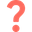
Проанализируйте результаты и сделайте выводы.

Результаты классификации методом k ближайших соседей показывают, что точность зависит от выбранной метрики и особенностей временных рядов. Для евклидовой метрики с z-нормализацией точность составила 0.675, что указывает на достаточно высокую, но не идеальную способность модели различать классы по амплитудным различиям рядов. При использовании DTW с нормализацией точность выросла до 0.700, что свидетельствует о лучшем учете формы временных рядов и меньшей зависимости от смещения или масштабных различий.